# **SALES ANALYSIS**

# *Import Libraries*

In [1]:
import numpy as np 

import pandas as pd 

import matplotlib.pyplot as plt 

import seaborn as sns

In [2]:
import warnings
warnings.simplefilter("ignore")

# *Load Data*

In [3]:
df = pd.read_excel(r"C:\Users\ADMIN\OneDrive\Desktop\Sales_EDA\Project Data new.xlsx")

In [4]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


# *BASIC EDA*

In [5]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

# *Unique Columns(State,Product_category,Sectors)*

# 
Display all unique State ,converts them into a CSV and saves them

In [8]:
State=df["State"].unique()
State=pd.DataFrame(State)
State

,0
0,Maharashtra
1,Andhra Pradesh
2,Uttar Pradesh
3,Karnataka
4,Gujarat
5,Himachal Pradesh
6,Delhi
7,Madhya Pradesh
8,Jharkhand
9,Kerala


In [9]:
State.to_csv("Total_States.csv",index=False)

Display all unique Product ,converts them into a CSV and saves them

In [10]:
Product_Categories=df["Product_Category"].unique()
Product_Categories=pd.DataFrame(Product_Categories)
Product_Categories

,0
0,Auto
1,Hand & Power Tools
2,Stationery
3,Tupperware
4,Footwear & Shoes
5,Furniture
6,Food
7,Games & Toys
8,Sports Products
9,Books


In [11]:
Product_Categories.to_csv("Product Category.csv",index=False)

# 
Display all unique Sector ,converts them into a CSV and saves them

In [12]:
Occupation=df["Occupation"].unique()
Sector=pd.DataFrame(Occupation)
Sector

,0
0,Healthcare
1,Govt
2,Automobile
3,Construction
4,Food Processing
5,Lawyer
6,IT Sector
7,Media
8,Banking
9,Retail


In [13]:
Sector.to_csv("Total Sectors.csv",index=False) 

# **Data Cleaning**

# 
Rename Occupation column to Sector

In [14]:
df.rename(columns={"Occupation":"sector"},inplace=True)

converts the Marital_Status values from 1 and 0 into readable labels — married and single

In [15]:
df["Marital_Status"] = df["Marital_Status"].astype(str).str.replace("1","Married")

In [16]:
df["Marital_Status"] = df["Marital_Status"].astype(str).str.replace("0","Single")

# 
deletes the Status and unnamed1 columns from the Data

In [17]:
df.drop(["unnamed1","Status"],axis=1,inplace=True)

# 
removes all rows containing missing (NaN) values from df

In [18]:
df.dropna(inplace=True)

# 
displays all unique age groups available in the Age Group

In [19]:
df["Age Group"].unique()

array(['26-35', '0-17', '18-25', '51-55', '46-50', '55+', '36-45'],
      dtype=object)

In [20]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,Married,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,Single,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,Single,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,Single,Karnataka,Southern,Agriculture,Office,3,206.0


In [131]:
df.to_csv("Cleaned data file.csv",index=False)

# **Data Vizualization**

# *Count Plot(Age_Group wise Gender Count)*

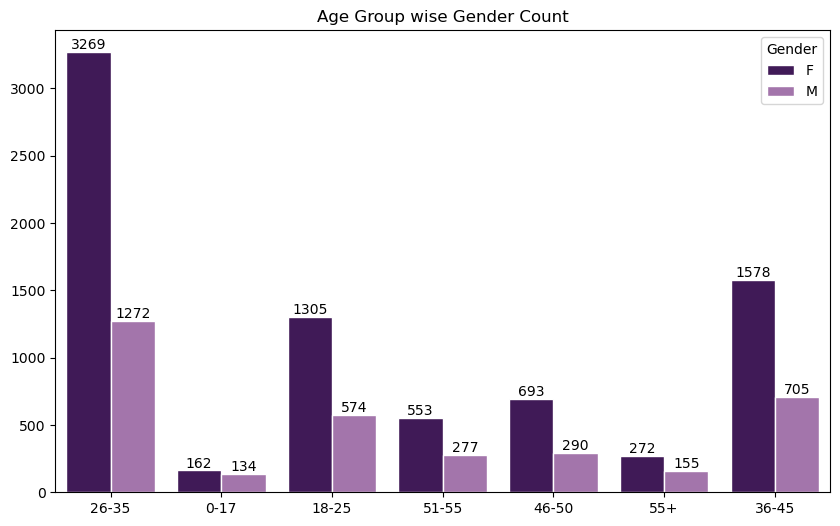

In [21]:
plt.figure(figsize=(10,6))

c1 = [ "#421061","#A96CB4"]

A1 = sns.countplot(x="Age Group",data=df,hue="Gender",palette=c1,edgecolor="white")

plt.title("Age Group wise Gender Count")

plt.xlabel("")

plt.ylabel("")

for y in A1.containers:
    A1.bar_label(y)

plt.show()

# 
Conclusion : 
            Female customers are higher than male customers across all age groups, indicating that females are the dominant customer


# *Line Plot(Sector wise Avg_Orders and Total_orders)*

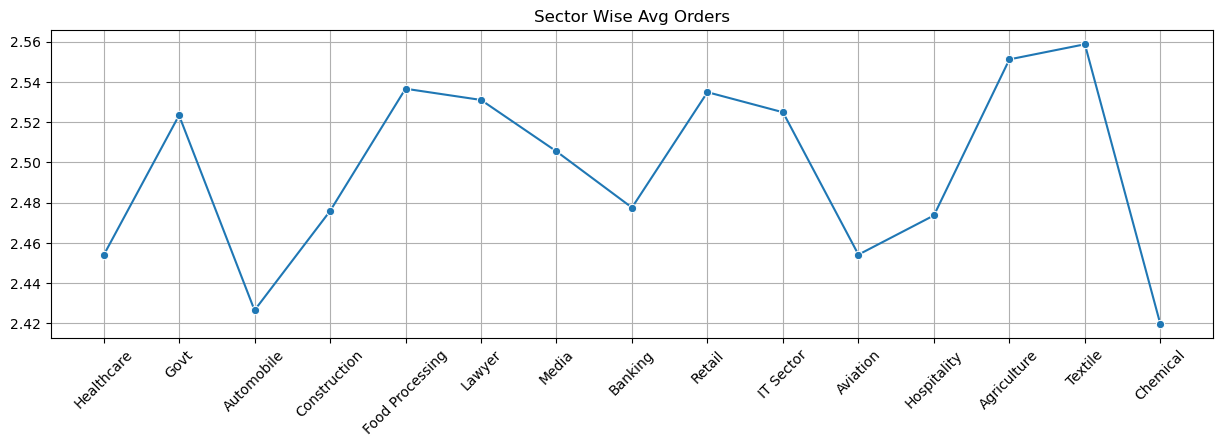

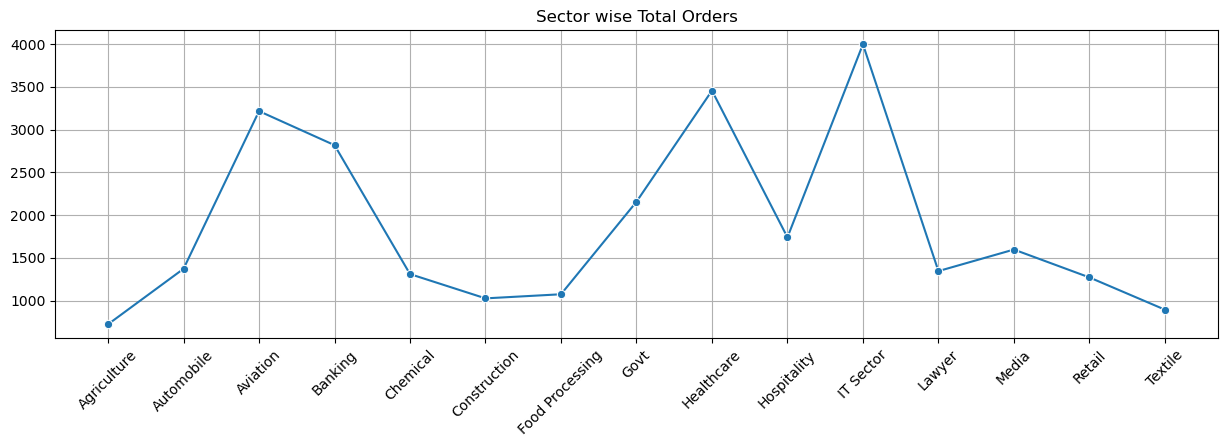

In [22]:
plt.figure(figsize=(15,4))

sns.lineplot(x="sector",y="Orders",data=df,ci=None,marker="o")

plt.title("Sector Wise Avg Orders")

plt.grid()

plt.xlabel("")

plt.ylabel("")

plt.xticks(rotation=45)

plt.show()


T1 = df.groupby("sector",as_index=False)["Orders"].sum()

plt.figure(figsize=(15,4))

sns.lineplot(x="sector",y="Orders",data=T1,ci=None,marker="o")

plt.title("Sector wise Total Orders")

plt.grid()

plt.xlabel("")

plt.ylabel("")

plt.xticks(rotation=45)

plt.show()


# 
Conclusion:
            The analysis shows that the IT sector records the highest total number of orders, indicating the strongest overall order volume among all sectors. However, the Textile sector has the highest average orders, suggesting consistently higher order activity per transaction.

# *pie chart(Zone wise Total amount)*

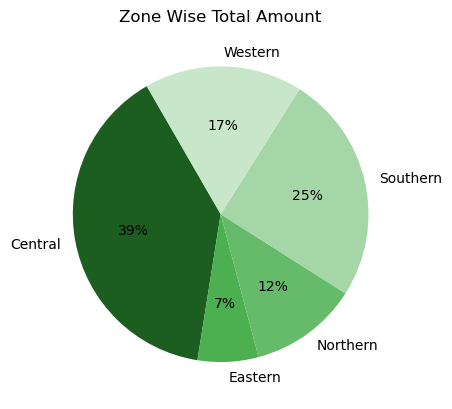

In [23]:
c2 = [
    
    "#C8E6C9",
    "#A5D6A7",
    "#66BB6A",
    "#4CAF50",
    "#1B5E20",
]
c2 = c2[::-1]

T2 = df.groupby("Zone",as_index=False)["Amount"].sum()

plt.pie(T2["Amount"],labels=T2["Zone"],autopct="%1.f%%",startangle=120,colors=c2)

plt.title("Zone Wise Total Amount")

plt.show()

# 
Conclusion : 
                The Central zone dominates regional performance by generating the largest share at 39%, followed closely by the Southern zone at 25%. Together, these top two regions account for nearly two-thirds of the total amount, while the Eastern zone represents the smallest contribution at 7%.

# *Bar plot (Top 10 State Amount)*

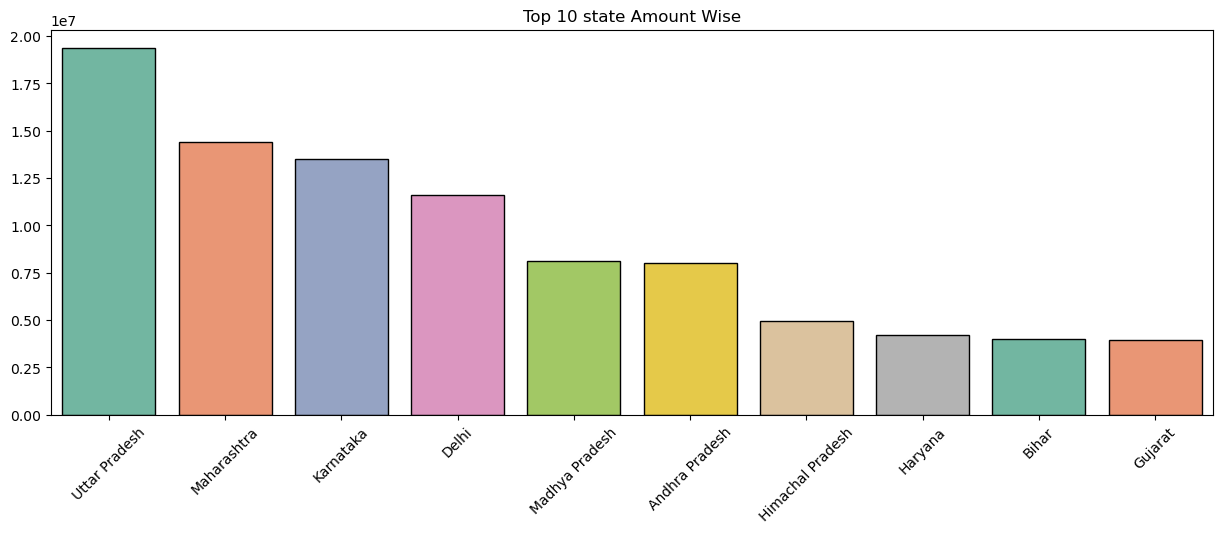

In [84]:
T3 = df.groupby("State",as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False).head(10)

plt.figure(figsize=(15,5))

sns.barplot(x="State",y="Amount",data=T3,palette="Set2",edgecolor="black")

plt.title("Top 10 state Amount Wise")

plt.xlabel("")

plt.ylabel("")

plt.xticks(rotation=45)

plt.show()

# 
Conclusion : 
            Uttar Pradesh leads state-wise performance by generating the highest amount (nearly 20 million), followed by Maharashtra and Karnataka. Meanwhile, states like Bihar and Gujarat contribute the lowest among the top 10, highlighting significant revenue concentration in the top four regions

# *CountPlot(Zone Wise Marital_Status)*

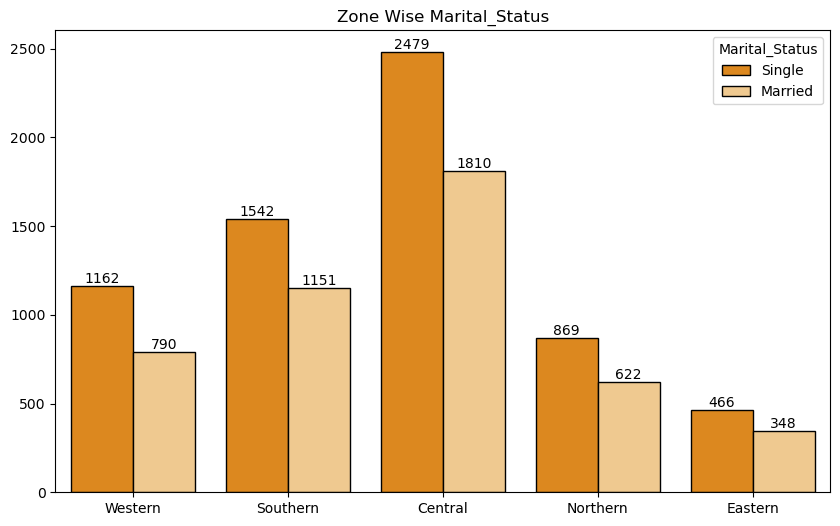

In [103]:
plt.figure(figsize=(10,6))

c6 = [ "#FB8C00","#FFCC80",]

J6 = sns.countplot(x="Zone",data=df,hue="Marital_Status",palette=c6,edgecolor="black")

plt.title("Zone Wise Marital_Status")

plt.xlabel("")

plt.ylabel("")

for y in J6.containers:
    J6.bar_label(y)

plt.show()

# 
Conclusion : 
            The Central zone leads overall count across all marital categories with 2,479 single and 1,810 married individuals, followed by the Southern zone. Across every region, single individuals consistently outnumber married individuals, with the lowest overall counts recorded in the Eastern zone.

# *Line Plot(Product Category wise Amount Count)*

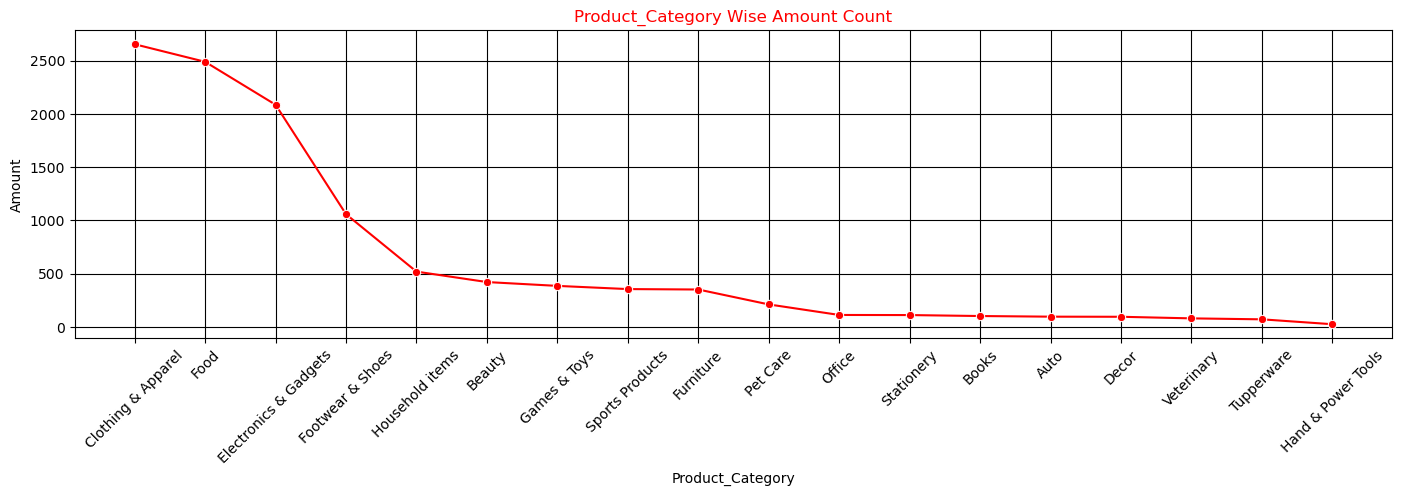

In [27]:
J1 = df.groupby("Product_Category",as_index=False)["Amount"].count().sort_values(by="Amount",ascending=False)

plt.figure(figsize=(17,4))

sns.lineplot(x="Product_Category",y="Amount",data=J1,ci=None,marker="o",color="red")

plt.title("Product_Category Wise Amount Count",color="red")

plt.grid(color="black")

plt.xticks(rotation=45)

plt.show()

# 
Conclusion : 
            Clothing & Apparel leads category volume with over 2,500 transactions, closely followed by Food and Electronics & Gadgets. A steep drop-off occurs after Footwear & Shoes, leaving niche categories like Tupperware and Hand & Power Tools with the lowest overall counts

# *Bar plot(Sector Wise Total Orders)*

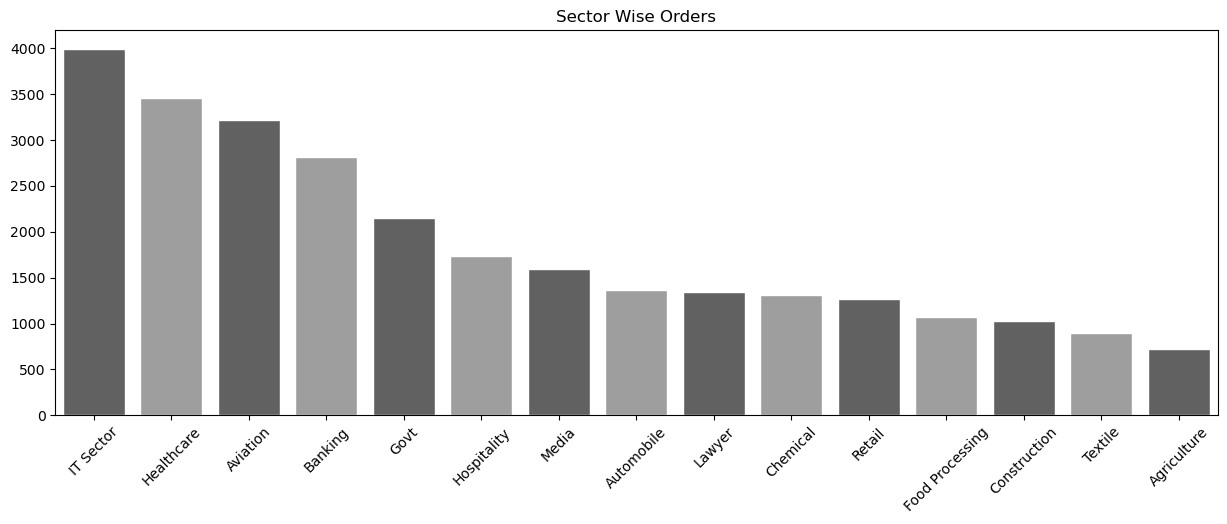

In [82]:
J2 = df.groupby("sector",as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False)

c4 = [ "#616161","#9E9E9E"]

plt.figure(figsize=(15,5))

sns.barplot(x="sector",y="Orders",data=J2,ci=None,edgecolor="white",palette=c4)

plt.title("Sector Wise Orders")

plt.xlabel("")

plt.ylabel("")

plt.xticks(rotation=45)

plt.show()

# 
Conclusion : 
            The IT Sector dominates order volume with nearly 4,000 orders, followed by Healthcare and Aviation. In contrast, sectors like Textile and Agriculture generate the lowest order counts, showing a heavy reliance on corporate and service-oriented industries.

# *Pie Chart(Age_Group wise Orders)*

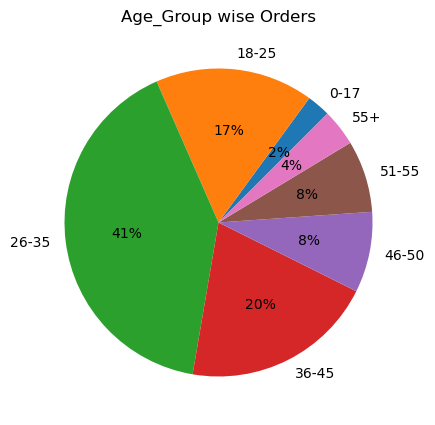

In [80]:
plt.figure(figsize=(15,5))

T2=df.groupby("Age Group",as_index=False)["Orders"].sum()

plt.pie(T2["Orders"],labels=T2["Age Group"],autopct="%1.f%%",startangle=45)

plt.title("Age_Group wise Orders")
plt.show()

# 
Conclusion : 
            The 26–35 age group drives total demand by placing the highest share of orders at 41%, closely followed by the 36–45 (20%) and 18–25 (17%) demographics. Combined, young to mid-aged adults generate over three-quarters of total order volume, while the 0–17 bracket represents the smallest contribution at just 2%.

# *BarPlot(State Wise Top 10 Orders)*

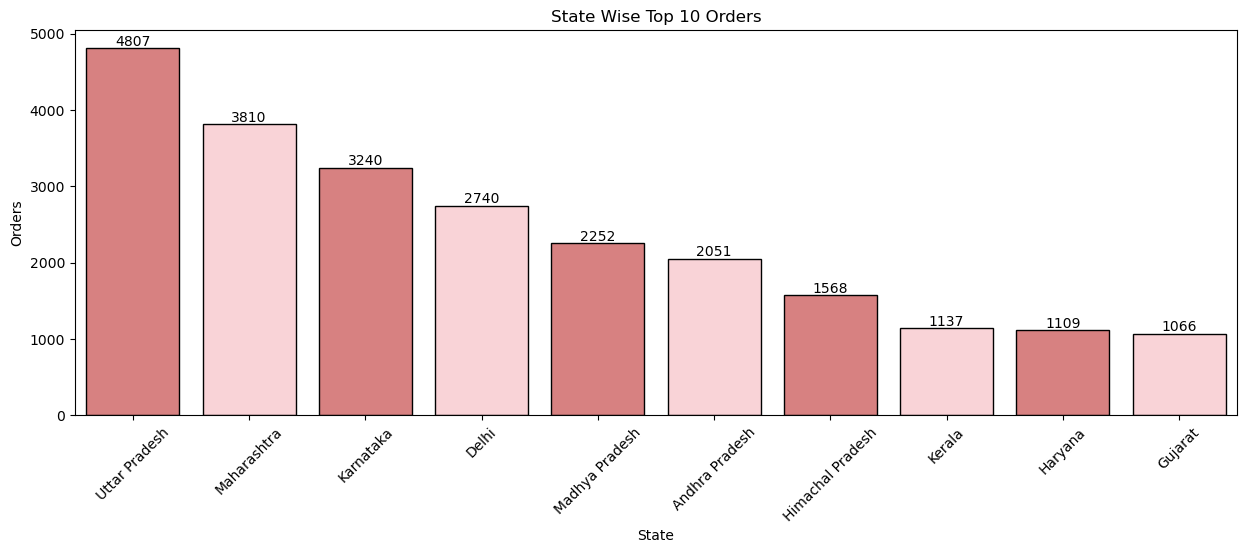

In [130]:
plt.figure(figsize=(15,5))

c5 = ["#E57373", "#FFCDD2"]

J8=df.groupby("State",as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False).head(10)

X9 = sns.barplot(x="State",y="Orders",data=J8,ci=None,palette=c5,edgecolor="black")

plt.title("State Wise Top 10 Orders")

plt.xticks(rotation=45)

for p in X9.containers:
    X9.bar_label(p)

plt.show()

# 
Conclusion : 
            Uttar Pradesh leads the top 10 states with the highest order volume at 4,807, followed closely by Maharashtra (3,810) and Karnataka (3,240). In contrast, Gujarat, Haryana, and Kerala record the lowest order counts in this group, each contributing just around 1,100 orders.